In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
import glob, os
from sklearn.manifold import TSNE
from sklearn.preprocessing import minmax_scale
from sklearn.manifold import SpectralEmbedding
import glob




In [2]:
def calc_price_from_tick(df):
    diff = abs(df.diff())
    min_diff = np.nanmin(diff.where(lambda x: x > 0))
    n_ticks = (diff / min_diff).round()
    return 0.01 / np.nanmean(diff / n_ticks)


def calculate_custom_wap_denormalized(df):
    """
    Groups by time_id to:
    1. Select the absolute best bid/ask across Level 1 and 2 for every row.
    2. Estimate the price multiplier (denormalization) based on minimum tick.
    3. Calculate the row-level WAP in real currency terms.
    """
    
    # Get tick-based multiplier per time_id
    price_cols = ['bid_price1', 'ask_price1', 'bid_price2', 'ask_price2']
    multipliers = df.groupby('time_id')[price_cols].apply(calc_price_from_tick)
    df = df.merge(multipliers.to_frame('multiplier'), left_on='time_id', right_index=True)
    
    # Apply multiplier to all price columns
    for col in price_cols:
        df[col] = df[col] * df['multiplier']

    df.drop(columns=['multiplier'], inplace=True)  # drop if not needed later
    
    df=add_wap_at_zero(df)
    
    return df

def calculate_bid_ask_spread(df):
    """
    For test data: calculate bid-ask spread for every row.
    Computes best_bid_price and best_ask_price from raw price columns,
    then adds spread values as 'bid_ask_spread' column to the dataframe.
    """
    df = df.copy()
    
    # compute best bid/ask prices from raw columns for all rows
    df['best_bid_price'] = np.maximum(df['bid_price1'], df['bid_price2'])
    df['best_ask_price'] = np.minimum(df['ask_price1'], df['ask_price2'])
    
    # calculate bid-ask spread for all rows
    df['bid_ask_spread'] = (df['best_ask_price']/df['best_bid_price']) - 1
    
    # drop intermediate columns if not needed later
    df.drop(columns=['best_bid_price', 'best_ask_price'], inplace=True)   
    return df

def calculate_volume(df):
    """
    For test data: calculate total volume for every row.
    Computes best_bid_size and best_ask_size from raw size columns,
    then adds total volume values as 'total_volume' column to the dataframe.
    """
    df = df.copy()
    df['total_volume'] = df[['bid_size1', 'bid_size2', 'ask_size1', 'ask_size2']].sum(axis=1)
    
    # drop intermediate columns if not needed later
    return df


def add_wap_at_zero(df):
    """
    For test data: calculate WAP for every row.
    Computes best_bid_price/size and best_ask_price/size from raw price/size columns,
    then adds WAP values as 'multiplier' column to the dataframe.
    """
    df = df.copy()
    
    # compute best bid/ask prices and sizes from raw columns for all rows
    df['best_bid_price'] = np.maximum(df['bid_price1'], df['bid_price2'])
    df['best_ask_price'] = np.minimum(df['ask_price1'], df['ask_price2'])
    
    # best_bid_size is the size at the best (highest) bid price
    df['best_bid_size'] = np.where(df['bid_price1'] >= df['bid_price2'], 
                                   df['bid_size1'], df['bid_size2'])
    
    # best_ask_size is the size at the best (lowest) ask price
    df['best_ask_size'] = np.where(df['ask_price1'] <= df['ask_price2'], 
                                   df['ask_size1'], df['ask_size2'])
    
    # calculate WAP for all rows
    df['wap'] = (df['best_bid_price'] * df['best_ask_size'] + 
                        df['best_ask_price'] * df['best_bid_size']) / (
                        df['best_bid_size'] + df['best_ask_size'])
    df.drop(columns=['best_bid_price', 'best_ask_price', 'best_bid_size', 'best_ask_size'], inplace=True)   
    return df



In [3]:
out_dir = r"Data\Optiver\individual_book_train_denorm"
os.makedirs(out_dir, exist_ok=True)


def fill_missing_seconds_in_bucket(df):
    """Ensure every time_id has rows for all 0..599 seconds_in_bucket, forward-filling values."""
    # Keep original order semantics per time_id and fill gaps with prior available row.
    df = df.sort_values(['time_id', 'seconds_in_bucket'])
    filled = (
        df.groupby('time_id', group_keys=False)
          .apply(lambda g: g.set_index('seconds_in_bucket')
                         .reindex(range(600))
                         .ffill()
                         .bfill()
                         .assign(time_id=g['time_id'].iloc[0]))
          .reset_index()
    )
    return filled[['time_id', 'seconds_in_bucket', 'wap', 'bid_ask_spread', 'total_volume']]


def process_file(path, out_dir):
    fname = os.path.basename(path)
    out_path = os.path.join(out_dir, fname)
    try:
        df = pd.read_csv(path)
        df = calculate_custom_wap_denormalized(df)
        df = calculate_bid_ask_spread(df)
        df = calculate_volume(df)
        df = df[['time_id', 'seconds_in_bucket', 'wap', 'bid_ask_spread', 'total_volume']]
        df = fill_missing_seconds_in_bucket(df)
        df.to_csv(out_path, index=False)
        return (fname, 'ok')
    except Exception as e:
        return (fname, f'error: {e}')

files = glob.glob(r"Data\Optiver\individual_book_train\stock_*.csv")
print(f"Found {len(files)} files to process")

# Choose number of workers: -1 uses all CPUs. If I/O bound, reduce this.
n_jobs = -1
results = Parallel(n_jobs=n_jobs, verbose=5)(delayed(process_file)(p, out_dir) for p in files)

# Summary
oks = [r for r in results if r[1] == 'ok']
errs = [r for r in results if r[1] != 'ok']
print(f"Completed: {len(oks)}; Failed: {len(errs)}")
if errs:
    print('Failures (first 10):')
    for fn, msg in errs[:10]:
        print('-', fn, msg)

Found 112 files to process


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   55.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  7.2min


Completed: 112; Failed: 0


[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed: 14.3min finished


In [ ]:

files = glob.glob(r"Data\Optiver\individual_book_train_denorm\stock_*.csv")
mult_list = []
for path in files:
    stock = os.path.basename(path).split('stock_')[-1].split('.csv')[0]
    # read seconds_in_bucket so we can index by the combination
    df_local = pd.read_csv(path, usecols=['time_id','seconds_in_bucket','wap'])
    # create a series indexed by (time_id, seconds_in_bucket)
    ser = df_local.set_index(['time_id','seconds_in_bucket'])['wap'].rename(stock)
    mult_list.append(ser)

# concat along columns; the index is now a MultiIndex of (time_id, seconds_in_bucket)

df_multiplier = pd.concat(mult_list, axis=1)
# ensure column order sorted by int value if possible
try:
    cols_sorted = sorted(df_multiplier.columns, key=lambda x: int(x))
    df_multiplier = df_multiplier[cols_sorted]
except Exception:
    pass

print(df_multiplier.head())
df_multiplier.to_csv('multiplier_allstocks_final.csv')
plt.figure(figsize=(15, 20))
ax = sns.stripplot(data=df_multiplier, orient='h', alpha=0.3, s=2, jitter=0.2,
                   order=df_multiplier.median().sort_values().index[::-1].tolist(), 
                   palette='Blues')
ax.tick_params(axis='y', which='major', labelsize=10)
plt.xlabel('price')
plt.title('Denormalized price distribution by stock')

In [7]:

files = glob.glob(r"Data\Optiver\individual_book_train_denorm\stock_*.csv")
mult_list = []
for path in files:
    stock = os.path.basename(path).split('stock_')[-1].split('.csv')[0]
    # read only second 0 for each time_id
    df_local = pd.read_csv(path, usecols=['time_id','seconds_in_bucket','wap'])
    df0 = df_local[df_local['seconds_in_bucket'] == 0]
    # create a series indexed by time_id only
    ser = df0.set_index('time_id')['wap'].rename(stock)
    mult_list.append(ser)

# concat along columns; the index is now time_id only

df_multiplier = pd.concat(mult_list, axis=1)
# ensure column order sorted by int value if possible
try:
    cols_sorted = sorted(df_multiplier.columns, key=lambda x: int(x))
    df_multiplier = df_multiplier[cols_sorted]
except Exception:
    pass

print(df_multiplier.head())
# optional save
df_multiplier.to_csv('multiplier_allstocks.csv')

                  0           1           2           3           4  \
time_id                                                               
5        193.649150  152.533206  123.541146  226.045064  620.055416   
11       199.213818  149.794162  128.734365  249.759134  614.713719   
16       208.833648  104.859106  118.658930  164.385663  533.602582   
31       216.210727  137.621764  138.369693  235.691130  657.057542   
62       214.533300  140.620881  137.182249  238.394933  639.367205   

                  5           6           7           8           9  ...  \
time_id                                                              ...   
5        740.619940  370.858389  246.111936  283.490706  239.522089  ...   
11       768.850360  411.976476  256.484692  278.103377  244.414485  ...   
16       584.136105  236.989429  208.117706  123.586702  177.741712  ...   
31       803.093700  358.864033  260.710477  194.174642  232.314595  ...   
62       766.373846  403.163793  250.443422  1

In [8]:
df_prices=pd.read_csv("multiplier_allstocks.csv", index_col=0)
df_prices_denorm_scaled = df_prices.fillna(df_prices.mean())

In [9]:


# Compress time_id x stock_id price matrix to 1D using t-SNE
emb = TSNE(
        n_components=1,
        perplexity=400,
        random_state=0,
        max_iter=2000
    )
emb_denorm = emb.fit_transform(df_prices_denorm_scaled)

In [10]:
# Sort by t-SNE embedding
df_prices_denorm_ordered = df_prices.iloc[np.argsort(-emb_denorm[:, 0])]

# Reverse order
df_prices_denorm_ordered = df_prices_denorm_ordered.reindex(
    df_prices_denorm_ordered.index[::-1]
)

# Apply rolling mean
df_prices_denorm_ordered = df_prices_denorm_ordered.rolling(10, min_periods=1).mean()
df_prices_denorm_ordered.to_csv("df_prices_denorm_ordered.csv")

In [11]:
# Reorder multiplier_allstocks_final using the correct time_id order from denorm_ordered
# Load the denorm_ordered file to get the correct time_id order
denorm_ordered = pd.read_csv('df_prices_denorm_ordered.csv', index_col=0)
correct_time_id_order = denorm_ordered.index.tolist()

# Load multiplier file with MultiIndex restored
df_mult = pd.read_csv('multiplier_allstocks_final.csv', index_col=[0, 1])

# Reset index to make time_id and seconds_in_bucket regular columns
df_mult_reordered = df_mult.reset_index()

# Create a mapping of time_id to its position in the correct order
time_id_order_map = {tid: i for i, tid in enumerate(correct_time_id_order)}

# Add a sort key column based on the correct_time_id_order
df_mult_reordered['_sort_key'] = df_mult_reordered['time_id'].map(time_id_order_map)

# Sort by the sort key (stable sorting preserves seconds_in_bucket order within each time_id)
df_mult_reordered = df_mult_reordered.sort_values('_sort_key').drop('_sort_key', axis=1)

# Restore MultiIndex
df_mult_reordered = df_mult_reordered.set_index(['time_id', 'seconds_in_bucket'])

# Save the reordered multiplier file
df_mult_reordered.to_csv('final.csv')
print("Multiplier file reordered and saved")

Multiplier file reordered and saved


In [ ]:
df_mult_reordered.plot(
    subplots=True,
    layout=(-1, 5),
    figsize=(15, 60),
    sharex=True,
    lw=1
)

plt.suptitle('Denormalized prices in recovered time order')
plt.subplots_adjust(top=0.97, wspace=0.3)

In [12]:
ordered = pd.read_csv('df_prices_denorm_ordered.csv')


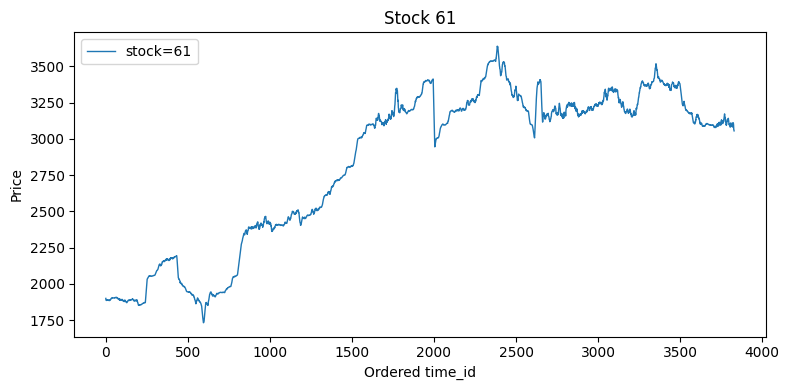

In [13]:

# visualize single stock (stock 4) from the ordered matrix
ordered = pd.read_csv('df_prices_denorm_ordered.csv')
if '61' in ordered.columns:
    plt.figure(figsize=(8, 4))
    plt.plot(ordered.index, ordered['61'], linewidth=1)
    plt.title('Stock 61')
    plt.xlabel('Ordered time_id')
    plt.ylabel('Price')
    plt.legend(['stock=61'])
    plt.tight_layout()
    plt.show()

